<a href="https://colab.research.google.com/github/GouthamBatthula/ObjectDetection_LabExam/blob/main/notebook2cc2b226c7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ashfakyeafi_road_vehicle_images_dataset_path = kagglehub.dataset_download('ashfakyeafi/road-vehicle-images-dataset')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -qr requirements.txt

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
data_path = "/kaggle/input/datasets/ashfakyeafi/road-vehicle-images-dataset"

In [ ]:
data_yaml = "/kaggle/input/datasets/ashfakyeafi/road-vehicle-images-dataset/trafic_data/data_1.yaml"

In [ ]:
import yaml

# Your original read-only YAML file
original_yaml = "/kaggle/input/datasets/ashfakyeafi/road-vehicle-images-dataset/trafic_data/data_1.yaml"

# Where we will save the new, corrected YAML file
new_yaml = "/kaggle/working/yolov5/custom_data.yaml"

# The absolute base path to your images
base_dir = "/kaggle/input/datasets/ashfakyeafi/road-vehicle-images-dataset/trafic_data"

# Read the original YAML
with open(original_yaml, 'r') as file:
    data = yaml.safe_load(file)

# Update the paths to be absolute
data['train'] = f"{base_dir}/train/images"
data['val'] = f"{base_dir}/valid/images"

# Save the updated configuration to the working directory
with open(new_yaml, 'w') as file:
    yaml.dump(data, file)

print("✅ custom_data.yaml created successfully with absolute paths!")

✅ custom_data.yaml created successfully with absolute paths!


In [ ]:
# Make sure we are in the yolov5 directory
%cd /kaggle/working/yolov5

# Run the training script using our new custom YAML file
!python train.py --img 640 --batch 16 --epochs 20 --data custom_data.yaml --weights yolov5s.pt --cache

/kaggle/working/yolov5
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-20 05:34:28.749409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776663268.772222     214 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776663268.779627     214 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776663268.800408     214 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776663268.800446     214 computation_placer.cc:177] computation p

In [ ]:
from IPython.display import FileLink
import os

# Path to your best weights from the recent training run
weights_path = '/kaggle/working/yolov5/runs/train/exp2/weights/best.pt'

if os.path.exists(weights_path):
    print("✅ Model found! Click the link below to download:")
    display(FileLink(weights_path))
else:
    print(f"❌ File not found at {weights_path}.")

✅ Model found! Click the link below to download:


/kaggle/working/yolov5/runs/train/exp2/weights/best.pt

In [ ]:
# Make sure you are in the yolov5 directory
%cd /kaggle/working/yolov5

# Run the validation script on your best weights
!python val.py --weights runs/train/exp2/weights/best.pt --data custom_data.yaml --img 640

/kaggle/working/yolov5
val: data=custom_data.yaml, weights=['runs/train/exp2/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-472-g7ca403a3 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7066762 parameters, 0 gradients, 15.9 GFLOPs
val: Scanning /kaggle/input/datasets/ashfakyeafi/road-vehicle-images-dataset/tra
val: WARNING ⚠️ /kaggle/input/datasets/ashfakyeafi/road-vehicle-images-dataset/trafic_data/valid/images/Pias--359-_PNG.rf.43bcf36efe5cf8c37552d2c45fffea60.jpg: 9 duplicate labels removed
val: WARNING ⚠️ /kaggle/input/datasets/ashfakyeafi/road-vehicle-images-dataset/trafic_data/valid/images/Pias--360-_PNG.rf.8405b0e44009a9300e0a1100ccf7d5b3.jpg: 7 duplicat

/kaggle/working/yolov5
Testing on image: Pias--359-_PNG.rf.43bcf36efe5cf8c37552d2c45fffea60.jpg
detect: weights=['runs/train/exp2/weights/best.pt'], source=/kaggle/input/datasets/ashfakyeafi/road-vehicle-images-dataset/trafic_data/valid/images/Pias--359-_PNG.rf.43bcf36efe5cf8c37552d2c45fffea60.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-472-g7ca403a3 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7066762 parameters, 0 gradients, 15.9 GFLOPs
image 1/1 /kaggle/input/datasets/ashfakyeafi/road-vehicle-images-dataset/trafic_data/valid/im

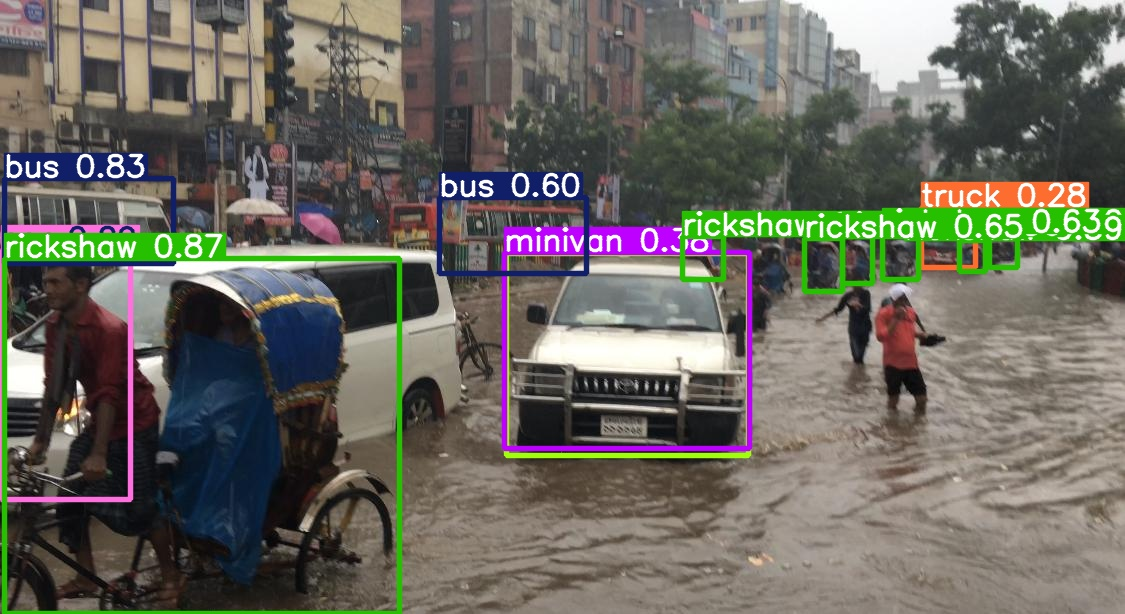

In [ ]:
import os
import glob
from IPython.display import Image, display

# 1. Ensure we are in the YOLOv5 directory
%cd /kaggle/working/yolov5

# 2. Provide the exact path to the specific image you want to test
specific_image_path = "/kaggle/input/datasets/ashfakyeafi/road-vehicle-images-dataset/trafic_data/valid/images/Pias--359-_PNG.rf.43bcf36efe5cf8c37552d2c45fffea60.jpg"

print(f"Testing on image: {os.path.basename(specific_image_path)}")

# 3. Run YOLOv5 inference using your best.pt weights
!python detect.py --weights runs/train/exp2/weights/best.pt --img 640 --conf 0.25 --source {specific_image_path}

# 4. Display the resulting image right here in the notebook
latest_detect_dir = max(glob.glob('runs/detect/exp*'), key=os.path.getmtime)
result_image = os.path.join(latest_detect_dir, os.path.basename(specific_image_path))

print("\n✅ Detection Complete! Here is the result:")
display(Image(filename=result_image))